# notebook 02 - task 1.1: review effort dimensions

**assignment requirement:** identify and define at least three different dimensions
of review effort that can be constructed from the dataset. for each dimension:
- state the variable name or formula used to compute it
- explain, in domain terms, what aspect of review effort it captures
- justify any preprocessing choice

we define **5 dimensions**, reusing the 3 from a1/a2 and adding 2 new ones
that capture distinct effort aspects.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")
from src.config.settings import (
    FIG_DIR,
    EFFORT_DIMENSIONS,
    EFFORT_DIM_LABELS,
    EFFORT_DIM_DESCRIPTIONS,
    AGENT_ORDER,
    COLOR_MAP,
)
from src.utils.helper import (
    load_clustering_ready,
    preprocess_effort_dims,
    compute_pairwise_corr,
    summarize_zeros,
)

FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

## 1. load data

In [3]:
df = load_clustering_ready()
print(f"agentic prs: {len(df):,}")
df.head(5)

agentic prs: 22,559


,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,is_agentic,n_formal_reviews,has_review_data,n_review_comments,time_to_merge_hours,total_additions,total_deletions,total_files_changed,total_churn,n_unique_reviewers,churn_per_review_cycle,task_type
0,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26 04:56:55+00:00,2025-07-26T22:12:24Z,2025-07-26 22:12:24+00:00,1025472321.000,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,True,0,False,0,17.258,38.000,38.000,11.000,76.000,0,76.000,refactor
1,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26 13:31:19+00:00,2025-07-26T13:37:22Z,2025-07-26 13:37:22+00:00,988488798.000,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,True,2,True,2,0.101,298.000,109.000,5.000,407.000,1,203.500,feat
2,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26 14:07:22+00:00,2025-07-26T14:45:30Z,2025-07-26 14:45:30+00:00,999285986.000,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,True,1,True,2,0.636,288.000,12.000,15.000,300.000,0,300.000,feat
3,3214555104,16658,Add function signature breaking change detector,<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,Claude_Code,17039389,harupy,closed,2025-07-09 05:35:26+00:00,2025-07-11T05:13:35Z,2025-07-11 05:13:35+00:00,136202695.000,https://api.github.com/repos/mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16658,True,8,True,7,47.636,620.000,0.000,3.000,620.000,2,77.500,feat
4,3214724259,5489,feat: add comprehensive test coverage for form...,## Summary\n\nThis PR enhances the forms plugi...,Claude_Code,82053242,wtfsayo,closed,2025-07-09 06:43:46+00:00,2025-07-09T06:44:02Z,2025-07-09 06:44:01+00:00,826170402.000,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5489,True,1,True,0,0.004,1013.000,340.000,6.000,1353.000,0,1353.000,feat


## 2. dimension definitions

### dimension 1: duration - `time_to_merge_hours`

**formula:** `(merged_at - created_at).total_seconds() / 3600`

**domain meaning:** wall-clock time from pr creation to merge. captures how long
reviewers needed to reach consensus. a long duration may indicate complexity,
disagreement among reviewers, or low priority. a short duration suggests quick
consensus or low scrutiny.

**uniqueness:** measures temporal extent of the review process. orthogonal to
counts (you can have many reviews quickly or few reviews slowly).

---

### dimension 2: iterations - `n_formal_reviews`

**formula:** `pr_reviews.groupby('pr_id').size()`

**domain meaning:** count of formal review submissions (approved, changes_requested,
commented). captures how many revision rounds were needed before the pr was accepted.
more rounds = more back-and-forth between author and reviewers.

**uniqueness:** measures procedural complexity of the review process - how many
times reviewers formally engaged. distinct from duration (a pr can sit for days
with one review) and depth (one review can have zero or many inline comments).

---

### dimension 3: depth - `n_review_comments`

**formula:** `pr_review_comments.groupby('pr_id').size()`

**domain meaning:** count of inline review comments on specific code lines. captures
the depth of scrutiny within review rounds. a high comment count indicates
detailed, line-by-line examination of the proposed changes.

**uniqueness:** measures granularity of review feedback. a pr can have many formal
review submissions with no inline comments (rubber-stamp reviews) or few formal
reviews with many inline comments (deep, focused scrutiny).

---

### dimension 4: breadth - `n_unique_reviewers`

**formula:** `pr_reviews[user_type=='user'].groupby('pr_id')['user'].nunique()`

**domain meaning:** count of distinct human reviewers who submitted a formal review.
captures the breadth of reviewer involvement - whether scrutiny comes from
many independent perspectives or is concentrated in a single reviewer.

**uniqueness:** measures reviewer diversity, not volume. a pr with 5 reviews
from 1 reviewer (5 iterations, 1 reviewer) is qualitatively different from
5 reviews from 5 different reviewers (5 iterations, 5 reviewers). the former
suggests iterative refinement with one person; the latter suggests broader
community scrutiny and potential disagreement.

---

### dimension 5: burden - `churn_per_review_cycle`

**formula:** `total_churn / n_formal_reviews` (total_churn when reviews = 0)

**domain meaning:** total lines changed per formal review round. captures the
cognitive load each review round imposes. when a reviewer must evaluate 500 lines
per round vs 50 lines per round, the effort required per iteration differs
substantially, even if the number of iterations is the same.

**uniqueness:** measures code volume per review opportunity. a pr with 3 reviews
and 300 lines changed imposes the same iteration count but 10x the per-round
burden as a pr with 3 reviews and 30 lines changed. this is not captured by
iterations, depth, or duration.

## 3. raw distribution analysis

In [4]:
df[EFFORT_DIMENSIONS].describe().T

,count,mean,std,min,25%,50%,75%,max
time_to_merge_hours,22559.000,12.843,66.877,0.001,0.005,0.039,0.727,1797.698
n_formal_reviews,22559.000,0.710,2.361,0.000,0.000,0.000,0.000,30.000
n_review_comments,22559.000,0.552,2.839,0.000,0.000,0.000,0.000,63.000
n_unique_reviewers,22559.000,0.256,0.641,0.000,0.000,0.000,0.000,6.000
churn_per_review_cycle,22559.000,194.158,393.552,0.000,17.000,60.000,181.000,3123.000


In [5]:
zero_df = summarize_zeros(df, EFFORT_DIMENSIONS)
zero_df

,dimension,n_zeros,pct_zeros,n_total
0,time_to_merge_hours,0,0.000,22559
1,n_formal_reviews,17434,77.282,22559
2,n_review_comments,20170,89.410,22559
3,n_unique_reviewers,18661,82.721,22559
4,churn_per_review_cycle,27,0.120,22559


effort dimensions: raw vs log1p transform

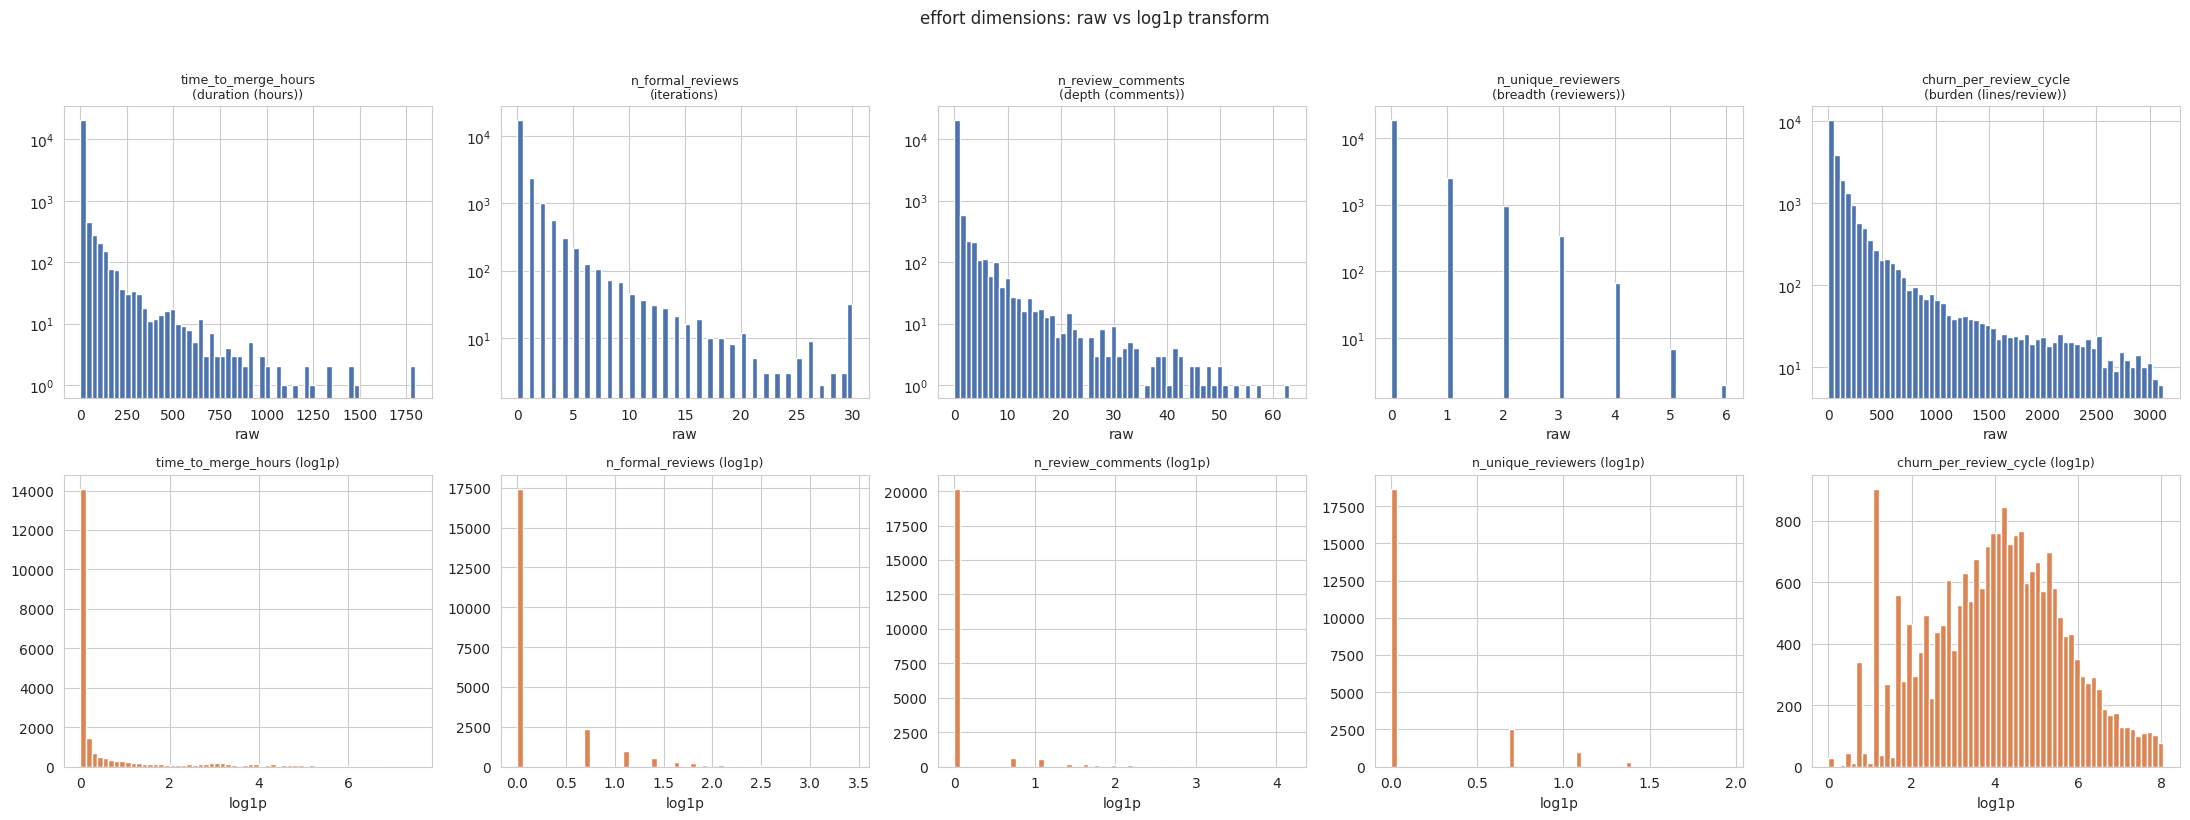

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for i, col in enumerate(EFFORT_DIMENSIONS):
    label = EFFORT_DIM_LABELS[col]
    # raw
    axes[0, i].hist(df[col], bins=60, color="#4C72B0", edgecolor="white")
    axes[0, i].set_title(f"{col}\n({label})", fontsize=9)
    axes[0, i].set_yscale("log")
    axes[0, i].set_xlabel("raw")

    # log1p
    axes[1, i].hist(np.log1p(df[col]), bins=60, color="#DD8452", edgecolor="white")
    axes[1, i].set_title(f"{col} (log1p)", fontsize=9)
    axes[1, i].set_xlabel("log1p")

fig.suptitle("effort dimensions: raw vs log1p transform", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_effort_dims_raw_vs_log1p.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. preprocessing justification: log1p transform

**choice:** apply `log1p(x) = log(1 + x)` to all 5 dimensions before clustering.

**rationale:**

1. **right skew:** all dimensions have extreme right tails (max >> median).
   k-means, gmm, and most clustering algorithms use euclidean distance, which
   is dominated by outliers in raw scale. log1p compresses the tail.

2. **zero-preservation:** unlike log(x), log1p(0) = 0. this is critical because
   77-89% of prs have zero formal reviews, review comments, or unique reviewers.
   log(x) would require imputation or dropping these prs, introducing bias.

3. **scale normalization:** dimensions have vastly different units (hours vs
   counts vs lines). log1p reduces scale differences before standardization.

4. **interpretable zeros:** a zero in log1p space still means "no review activity"
   - the semantic meaning is preserved.

after log1p, we will apply standard scaling (z-score) to give each dimension
equal weight in distance calculations. this two-step preprocessing
(log1p + standardscaler) is the standard approach for clustering on
skewed, mixed-scale data.

## 5. apply preprocessing

log1p-transformed dimension statistics:

In [7]:
df = preprocess_effort_dims(df, EFFORT_DIMENSIONS)
log_cols = [f"{c}_log" for c in EFFORT_DIMENSIONS]
df[log_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
time_to_merge_hours_log,22559.000,0.690,1.346,0.001,0.005,0.038,0.546,7.495
n_formal_reviews_log,22559.000,0.267,0.571,0.000,0.000,0.000,0.000,3.434
n_review_comments_log,22559.000,0.156,0.515,0.000,0.000,0.000,0.000,4.159
n_unique_reviewers_log,22559.000,0.151,0.347,0.000,0.000,0.000,0.000,1.946
churn_per_review_cycle_log,22559.000,4.044,1.647,0.000,2.890,4.111,5.204,8.047


## 6. dimension uniqueness check: pairwise correlation

if two dimensions are highly correlated, they may be redundant in the
clustering feature space. we check spearman rank correlation on the
raw values (non-parametric, robust to skew).

spearman correlation: effort dimensions

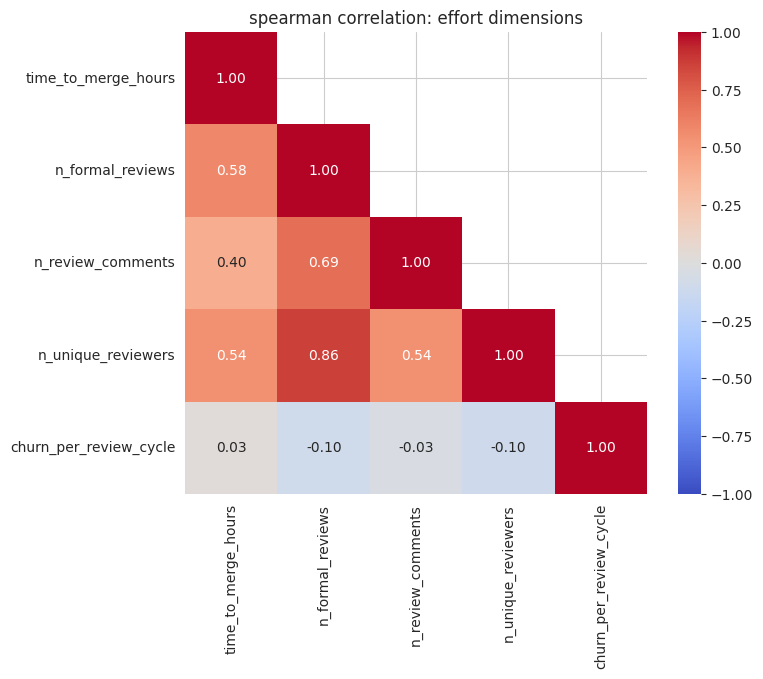

In [8]:
corr = compute_pairwise_corr(df, EFFORT_DIMENSIONS)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    ax=ax,
)
ax.set_title("spearman correlation: effort dimensions")
fig.savefig(FIG_DIR / "02_effort_dims_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

pairwise spearman correlations:

In [9]:
print(corr.round(3).to_string())

                        time_to_merge_hours  n_formal_reviews  n_review_comments  n_unique_reviewers  churn_per_review_cycle
time_to_merge_hours                   1.000             0.580              0.397               0.544                   0.029
n_formal_reviews                      0.580             1.000              0.690               0.863                  -0.097
n_review_comments                     0.397             0.690              1.000               0.541                  -0.035
n_unique_reviewers                    0.544             0.863              0.541               1.000                  -0.103
churn_per_review_cycle                0.029            -0.097             -0.035              -0.103                   1.000


### correlation interpretation

- `n_formal_reviews` and `n_unique_reviewers` have the highest correlation
  (rho ~ 0.86). this is expected: more reviewers tend to submit more reviews.
  however, they capture distinct aspects: procedural iterations vs reviewer
  breadth. a single reviewer submitting 5 reviews (high iterations, low breadth)
  is meaningfully different from 5 reviewers each submitting 1 review.
- `n_formal_reviews` and `n_review_comments` are moderately correlated (rho ~ 0.69).
  more review rounds tend to accumulate more inline comments, but the relationship
  is far from deterministic.
- `churn_per_review_cycle` is largely independent of all count-based metrics
  (all |rho| < 0.11). this confirms it captures a distinct effort axis.
- `time_to_merge_hours` is moderately correlated with count metrics (rho 0.4-0.6)
  but not so much as to be redundant - long prs can have few or many reviews.

**no pair exceeds rho = 0.9**, confirming each dimension adds unique information
to the clustering feature space.

## 7. per-agent effort profiles

check whether effort dimensions vary across coding agents. this helps
validate that the dimensions capture meaningful variation.

In [10]:
agent_profiles = (
    df.groupby("agent")[EFFORT_DIMENSIONS]
    .median()
    .reindex(AGENT_ORDER)
)
agent_profiles

,time_to_merge_hours,n_formal_reviews,n_review_comments,n_unique_reviewers,churn_per_review_cycle
agent,,,,,
OpenAI_Codex,0.014,0.000,0.000,0.000,62.000
Devin,1.437,1.000,0.000,1.000,51.000
Copilot,12.929,3.000,0.000,1.000,34.286
Cursor,0.468,1.000,0.000,0.000,97.333
Claude_Code,0.938,0.000,0.000,0.000,173.000


effort dimensions by agent (outliers hidden)

/tmp/ipykernel_16352/253060831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16352/253060831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16352/253060831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16352/253060831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16352/253060831.py:4: FutureWarning: 

Passin

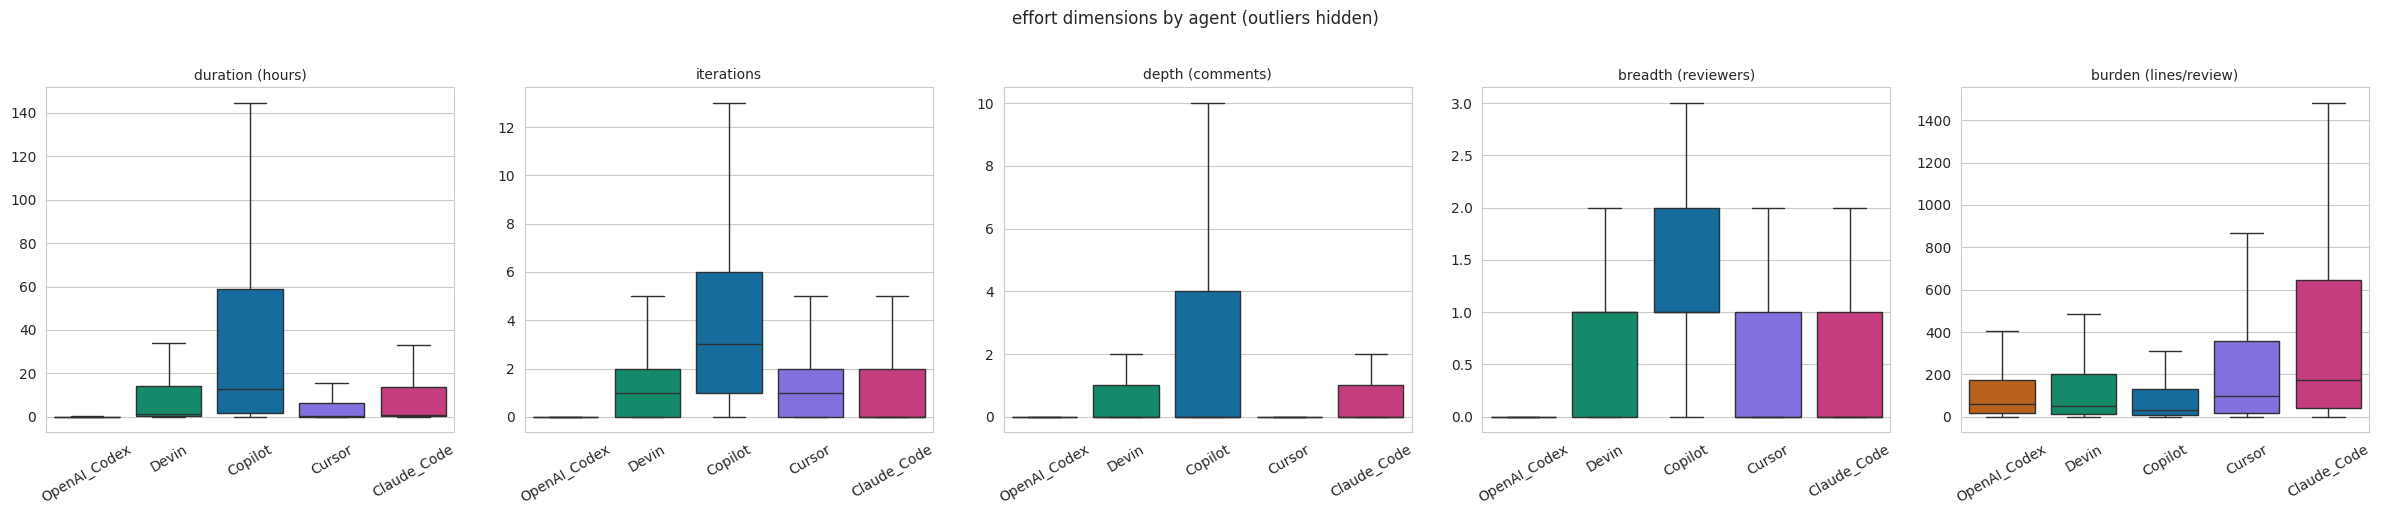

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, col in zip(axes, EFFORT_DIMENSIONS):
    sns.boxplot(
        data=df,
        x="agent",
        y=col,
        order=AGENT_ORDER,
        palette=COLOR_MAP,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(EFFORT_DIM_LABELS[col], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("effort dimensions by agent (outliers hidden)", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_effort_dims_by_agent.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. summary: dimension table for report

this table summarizes all 5 dimensions for inclusion in the assignment report.

In [12]:
summary_rows = []
for col in EFFORT_DIMENSIONS:
    summary_rows.append({
        "dimension": col,
        "label": EFFORT_DIM_LABELS[col],
        "median": df[col].median(),
        "mean": df[col].mean(),
        "std": df[col].std(),
        "pct_zero": 100 * (df[col] == 0).sum() / len(df),
        "skew": df[col].skew(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dimension,label,median,mean,std,pct_zero,skew
0,time_to_merge_hours,duration (hours),0.039,12.843,66.877,0.000,10.945
1,n_formal_reviews,iterations,0.000,0.710,2.361,77.282,6.859
2,n_review_comments,depth (comments),0.000,0.552,2.839,89.410,9.727
3,n_unique_reviewers,breadth (reviewers),0.000,0.256,0.641,82.721,2.943
4,churn_per_review_cycle,burden (lines/review),60.000,194.158,393.552,0.120,4.043


In [13]:
out_path = FIG_DIR / "02_dimension_summary.csv"
summary_df.to_csv(out_path, index=False)
print(f"saved to {out_path}")

saved to /mnt/d/career/digilians/queens/cisc-839-topics-in-information-system/cisc839-assignment-3/docs/06-figs/02_dimension_summary.csv
